In [35]:
import pandas as pd
from shapely.geometry import Point
import requests
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import json
import csv
import time
import folium
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import geopandas as gpd
import matplotlib.pyplot as plt
import glob
import os

In [36]:
# Getting locations of police stations in metropolitan area
stations = [
    ("Acton Police Station", "W3 9BH"),
    ("Bethnal Green Police Station", "E2 9NZ"),
    ("Brixton Police Station", "SW9 7DD"),
    ("Bromley Police Station", "BR1 1ER"),
    ("Charing Cross Police Station", "WC2N 4JP"),
    ("Chingford Police Station", "E4 7EA"),
    ("Colindale Police Station", "NW9 5TW"),
    ("Croydon Police Station", "CR9 1BP"),
    ("Dagenham Police Station", "RM10 7TU"),
    ("Edmonton Police Station", "N9 0PW"),
    ("Hammersmith Police Station", "W6 7NX"),
    ("Hayes Police Station", "UB4 8HU"),
    ("Islington Police Station", "N1 0YY"),
    ("Lavender Hill Police Station", "SW11 1JX"),
    ("Lewisham Police Station", "SE13 5JZ"),
    ("Plumstead Police Station", "SE18 1JY"),
    ("Stoke Newington Police Station", "N16 8DS"),
    ("Stratford Police Station", "E15 4SG"),
    ("Sutton Police Station", "SM1 4RF"),
    ("Twickenham Police Station", "TW1 3SY"),
    ("Walworth Police Station", "SE17 3BB"),
    ("Wembley Police Station", "HA0 2HH"),
]

OUTPUT_FILE = "metropolitan_police_stations.csv"

with open(OUTPUT_FILE, "w", newline="", encoding="utf-8") as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(["Station", "Postcode", "Latitude", "Longitude"])

    for name, postcode in stations:
        url = f"https://api.postcodes.io/postcodes/{postcode}"
        response = requests.get(url)

        if response.status_code == 200:
            data = response.json()["result"]
            latitude = data["latitude"]
            longitude = data["longitude"]
            writer.writerow([name, postcode, latitude, longitude])
        else:
            writer.writerow([name, postcode, None, None])
        time.sleep(0.2)

print(f"\nDataset written to {OUTPUT_FILE}")


Dataset written to metropolitan_police_stations.csv


In [37]:
# LSOA locations
base_path = "LB_shp"
shapefiles = glob.glob(os.path.join(base_path, "**/*.shp"), recursive=True)
print(f"Found {len(shapefiles)} borough shapefiles")
lsoa_gdfs = [gpd.read_file(shp) for shp in shapefiles]
lsoa_london = gpd.GeoDataFrame(
    pd.concat(lsoa_gdfs, ignore_index=True),
    crs=lsoa_gdfs[0].crs
)
print(lsoa_london.columns)

Found 33 borough shapefiles
Index(['lsoa21cd', 'lsoa21nm', 'msoa21cd', 'msoa21nm', 'lad22cd', 'lad22nm',
       'geometry'],
      dtype='str')


In [38]:
# Loading all crime data and clustering
df_crimes = pd.read_csv("london_all_data_uncleaned.csv").copy()
df_crimes = df_crimes.dropna(subset=["LSOA code"])
df_crimes = df_crimes.dropna(subset=["Crime type"])
df_crimes = df_crimes.drop(columns=["Context"])

df_lsoa_crimes = (df_crimes.groupby(["LSOA code", "Crime type"]).size().reset_index(name="count"))
X = df_lsoa_crimes.pivot_table(index="LSOA code", columns="Crime type", values="count", fill_value=0)

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Chosing number of clusters

# # Elbow method
# inertia = []
# K = range(2, 15)
# for k in K:
#     km = KMeans(n_clusters=k, random_state=42, n_init=10)
#     km.fit(X_scaled)
#     inertia.append(km.inertia_)

# plt.plot(K, inertia, marker="o")
# plt.xlabel("Number of clusters (k)")
# plt.ylabel("Inertia")
# plt.title("Elbow Method")
# plt.show()
# # 6 or 7 seems to be the best

# # Silhouette score
# from sklearn.metrics import silhouette_score
# scores = []
# for k in K:
#     km = KMeans(n_clusters=k, random_state=42, n_init=10)
#     labels = km.fit_predict(X_scaled)
#     scores.append(silhouette_score(X_scaled, labels))

# plt.plot(K, scores, marker="o")
# plt.xlabel("Number of clusters (k)")
# plt.ylabel("Silhouette Score")
# plt.title("Silhouette Analysis")
# plt.show()
# # 1, 2 are best, after that 6 is best.

# Clustering 
k = 6
kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(X_scaled)
X["cluster"] = clusters


# interpertation
cluster_profile = X.groupby("cluster").mean()
city_avg = X.drop(columns=["cluster"]).mean()
relative_profile = cluster_profile.div(city_avg)

## Top n for each cluster
def top_crimes(row, n=3):
    return row.sort_values(ascending=False).head(n)
cluster_signatures = relative_profile.apply(top_crimes, axis=1)

def label_cluster(row):
    top = row.idxmax()

    if "Violence" in row.index and row["Violence and sexual offences"] > 1.5:
        return "Violence & public order hotspot"

    if row["Shoplifting"] > 1.5:
        return "Retail theft zone"

    if row["Vehicle crime"] > 1.5 or row["Burglary"] > 1.5:
        return "Property crime area"

    if row["Theft from the person"] > 1.5 or row["Bicycle theft"] > 1.5:
        return "Transport theft zone"

    return "Low / mixed crime area"
cluster_labels = cluster_signatures.apply(label_cluster, axis=1)
cluster_labels

cluster
0       Property crime area
1    Low / mixed crime area
2         Retail theft zone
3      Transport theft zone
4         Retail theft zone
5         Retail theft zone
dtype: str

In [39]:
# Merging clustering and LSOA locations
clusters = X.reset_index()[["LSOA code", "cluster"]]

# Merge
lsoa_clustered = lsoa_london.merge(
    clusters,
    left_on="lsoa21cd",
    right_on="LSOA code",
    how="left"
)
lsoa_clustered

,lsoa21cd,lsoa21nm,msoa21cd,msoa21nm,lad22cd,lad22nm,geometry,LSOA code,cluster
0,E01000011,Barking and Dagenham 016C,E02000017,Barking and Dagenham 016,E09000002,Barking and Dagenham,"POLYGON ((544607.954 184727.846, 544620.667 18...",E01000011,1.0
1,E01000046,Barking and Dagenham 017D,E02000018,Barking and Dagenham 017,E09000002,Barking and Dagenham,"POLYGON ((547258.972 184378.376, 547259.861 18...",E01000046,0.0
2,E01000051,Barking and Dagenham 021D,E02000022,Barking and Dagenham 021,E09000002,Barking and Dagenham,"POLYGON ((544603.471 183903.184, 544620.396 18...",E01000051,0.0
3,E01000077,Barking and Dagenham 008F,E02000009,Barking and Dagenham 008,E09000002,Barking and Dagenham,"POLYGON ((547548.035 185377.027, 547545.923 18...",E01000077,0.0
4,E01000083,Barking and Dagenham 007F,E02000008,Barking and Dagenham 007,E09000002,Barking and Dagenham,"POLYGON ((547934.06 186229.42, 547931.391 1861...",E01000083,0.0
...,...,...,...,...,...,...,...,...,...
4989,E01004727,Westminster 008D,E02000967,Westminster 008,E09000033,Westminster,"POLYGON ((527686.246 183502.219, 527697.728 18...",E01004727,5.0
4990,E01035716,Westminster 013G,E02000972,Westminster 013,E09000033,Westminster,"POLYGON ((529365.209 181301.039, 529349.069 18...",E01035716,3.0
4991,E01004731,Westminster 020A,E02000979,Westminster 020,E09000033,Westminster,"POLYGON ((529396.801 179907.419, 529469.883 17...",E01004731,4.0
4992,E01004736,Westminster 018C,E02000977,Westminster 018,E09000033,Westminster,"POLYGON ((529666.73 180792.554, 529667.7 18079...",E01004736,2.0


<Axes: >

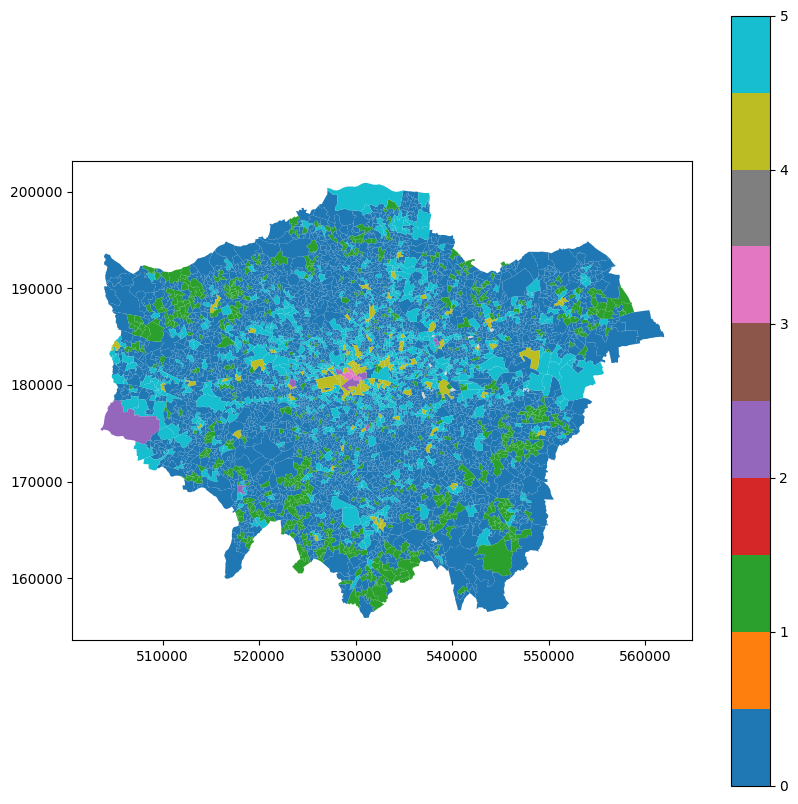

In [40]:
lsoa_clustered.plot(
    column="cluster",
    cmap="tab10",
    legend=True,
    figsize=(10, 10),
    missing_kwds={"color": "lightgrey"}
)

In [41]:
stations = pd.read_csv("metropolitan_police_stations.csv")

stations_gdf = gpd.GeoDataFrame(
    stations,
    geometry=gpd.points_from_xy(stations["Longitude"], stations["Latitude"]),
    crs="EPSG:4326"
)

# lsoa_clustered = lsoa_clustered.to_crs(epsg=4326)
stations_gdf = stations_gdf.to_crs(epsg=27700)
lsoa_clustered = lsoa_clustered.to_crs(epsg=27700)
stations_gdf["geometry"] = stations_gdf.geometry.buffer(2000)

lsoa_clustered = lsoa_london.merge(
    X,
    left_on="lsoa21cd",
    right_index=True,
    how="left"
)

joined = gpd.sjoin(
    lsoa_clustered,
    stations_gdf[["Station", "geometry"]],
    predicate="intersects",
    how="inner"
)

crime_cols = [
    "Anti-social behaviour",
    "Bicycle theft",
    "Burglary",
    "Criminal damage and arson",
    "Drugs",
    "Other crime",
    "Other theft",
    "Possession of weapons",
    "Public order",
    "Robbery",
    "Shoplifting",
    "Theft from the person",
    "Vehicle crime",
    "Violence and sexual offences"
]

station_profiles = joined.groupby("Station")[crime_cols].mean()

def classify_station(row):
    v = row["Violence and sexual offences"]
    p = row["Public order"]
    b = row["Burglary"]
    veh = row["Vehicle crime"]
    shop = row["Shoplifting"]
    rob = row["Robbery"]
    drugs = row["Drugs"]
    antisocial = row["Anti-social behaviour"]

    if v > 1.2 and p > 1.2:
        return "Night-time economy / violence response"

    if shop > 1.2:
        return "Retail crime enforcement"

    if b > 1.2 or veh > 1.2:
        return "Residential property crime"

    if rob > 1.2:
        return "High street robbery / street crime"

    if drugs > 1.2:
        return "Drug enforcement focus"

    if antisocial > 1.2:
        return "Anti-social behaviour hotspot"

    return "Mixed urban policing demand"

station_profiles["role"] = station_profiles.apply(classify_station, axis=1)

crime_color_map = {
    "Violence and sexual offences": "red",
    "Public order": "darkred",
    "Robbery": "orange",
    "Burglary": "cadetblue",
    "Vehicle crime": "blue",
    "Bicycle theft": "lightblue",
    "Theft from the person": "purple",
    "Shoplifting": "green",
    "Other theft": "lightgreen",
    "Anti-social behaviour": "gray",
    "Criminal damage and arson": "black",
    "Drugs": "pink",
    "Possession of weapons": "darkpurple",
    "Other crime": "beige"
}
station_profiles["dominant_crime"] = station_profiles[crime_cols].idxmax(axis=1)
station_profiles["dominance_ratio"] = (
    station_profiles[crime_cols].max(axis=1) /
    station_profiles[crime_cols].mean(axis=1)
)



stations_map = stations_gdf.merge(
    station_profiles[["dominant_crime", "dominance_ratio"]],
    left_on="Station",
    right_index=True,
    how="left"
)

m = folium.Map(location=[51.5074, -0.1278], zoom_start=10, tiles="cartodbpositron")

folium.Choropleth(
    geo_data=lsoa_clustered.to_crs(4326).to_json(),
    data=lsoa_clustered,
    columns=["lsoa21cd", "cluster"],
    key_on="feature.properties.lsoa21cd",
    fill_color="Set1",
    fill_opacity=0.4,
    line_opacity=0.1,
    legend_name="Crime Cluster"
).add_to(m)

for _, row in stations_map.to_crs(4326).iterrows():

    crime = row["dominant_crime"]
    color = crime_color_map.get(crime, "blue")

    popup_html = f"""
    <b>{row['Station']}</b><br>
    Dominant crime: {crime}<br>
    Dominance ratio: {row['dominance_ratio']:.2f}
    """

    folium.Marker(
        location=[row["Latitude"], row["Longitude"]],
        popup=popup_html,
        icon=folium.Icon(
            color=color,
            icon="shield",
            prefix="fa"
        )
    ).add_to(m)

folium.LayerControl().add_to(m)
m.save("london_police_stations_colored_by_crime.html")

THIRD VERSION (EXPLANED IN SSA 3) OF CLUSTERING

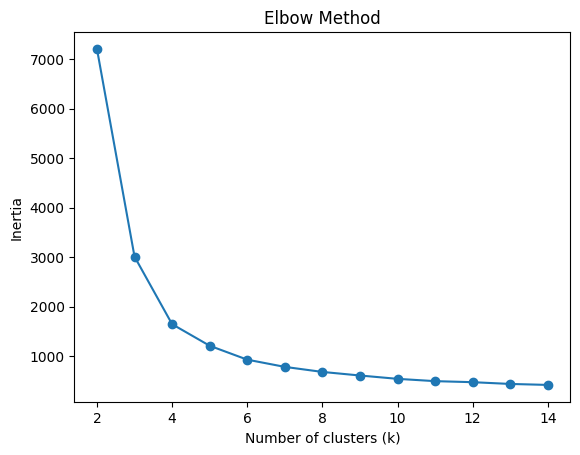

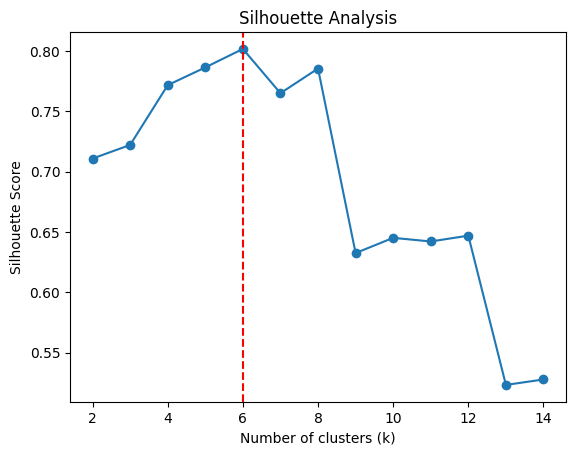

In [42]:
from sklearn.cluster import KMeans

df_lsoa_crimes = (df_crimes.groupby(["LSOA code", "Crime type"]).size().reset_index(name="count"))
X_3 = df_lsoa_crimes.pivot_table(index="LSOA code", columns="Crime type", values="count", fill_value=0)
X_prop = X_3.div(X_3.sum(axis=1), axis=0)

kmeans = KMeans(
    n_clusters=6,
    random_state=42,
    n_init=20
)

clusters_3 = kmeans.fit_predict(X_prop)
X_prop["cluster"] = clusters_3

lsoa_clustered_3 = lsoa_london.merge(
    X_prop,
    left_on="lsoa21cd",
    right_on="LSOA code",
    how="left"
)

# # resourch_weight Version 1
# crime_total = X_3.sum(axis=1)
# crime_total.index.name = "lsoa21cd"

# lsoa_clustered_3 = lsoa_clustered_3.merge(
#     crime_total.rename("resource_multiplier"),
#     left_on="lsoa21cd",
#     right_index=True,
#     how="left"
# )

# Resourch weight with severity score
from crime_weight import crime_weights

crime_total = X_3.sum(axis=1)
crime_total.index.name = "lsoa21cd"

crime_total["total_sev_score"] = sum(
    X_3[col] * weight
    for col, weight in crime_weights.items()
    if col in X_3.columns
)

crime_total["total_sev_score"]

lsoa_clustered_3 = lsoa_clustered_3.merge(
    crime_total["total_sev_score"].rename("resource_multiplier"),
    left_on="lsoa21cd",
    right_index=True,
    how="left"
)

# Elbow method
inertia = []
K = range(2, 15)
for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_prop)
    inertia.append(km.inertia_)

plt.plot(K, inertia, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()
# 6 or 7 seems to be the best

# Silhouette score
from sklearn.metrics import silhouette_score
scores = []
for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_prop)
    scores.append(silhouette_score(X_prop, labels))

plt.plot(K, scores, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")
plt.axvline(x=6, color='r', linestyle='--')
plt.show()
# 1, 2 are best, after that 6 is best.

# # interpertation
# cluster_profile = X.groupby("cluster").mean()
# city_avg = X.drop(columns=["cluster"]).mean()
# relative_profile = cluster_profile.div(city_avg)

# ## Top n for each cluster
# def top_crimes(row, n=3):
#     return row.sort_values(ascending=False).head(n)
# cluster_signatures = relative_profile.apply(top_crimes, axis=1)

# def label_cluster(row):
#     top = row.idxmax()

#     if "Violence" in row.index and row["Violence and sexual offences"] > 1.5:
#         return "Violence & public order hotspot"

#     if row["Shoplifting"] > 1.5:
#         return "Retail theft zone"

#     if row["Vehicle crime"] > 1.5 or row["Burglary"] > 1.5:
#         return "Property crime area"

#     if row["Theft from the person"] > 1.5 or row["Bicycle theft"] > 1.5:
#         return "Transport theft zone"

#     return "Low / mixed crime area"
# cluster_labels = cluster_signatures.apply(label_cluster, axis=1)
# cluster_labels

In [43]:
# Cluster profile
def name_cluster(row):
    if row["Violence and sexual offences"] > 0.25:
        return "Violence & safeguarding specialists"

    if row["Drugs"] > 0.20:
        return "Drugs & organised crime specialists"

    if row["Burglary"] + row["Vehicle crime"] > 0.35:
        return "Property crime specialists"

    if row["Shoplifting"] + row["Other theft"] > 0.40:
        return "Retail & theft specialists"

    if row["Anti-social behaviour"] + row["Public order"] > 0.40:
        return "Neighbourhood & public order policing"

    return "Mixed general policing demand"

lsoa_clustered_3["cluster_name"] = lsoa_clustered_3.apply(name_cluster, axis=1)

In [44]:
cluster_color_map = {
    "Violence & safeguarding specialists": "#d73027",
    "Drugs & organised crime specialists": "#7b3294",
    "Property crime specialists": "#4575b4",
    "Retail & theft specialists": "#1a9850",
    "Neighbourhood & public order policing": "#f46d43",
    "Mixed general policing demand": "#999999"
}

def style_function(feature):
    name = feature["properties"].get("cluster_name", "Unknown")
    color = cluster_color_map.get(name, "#999999")

    return {
        "fillColor": color,
        "color": "black",
        "weight": 0.2,
        "fillOpacity": feature["properties"].get("opacity", 0.6)
    }

In [45]:
lsoa_clustered_3["opacity"] = (
    lsoa_clustered_3["resource_multiplier"] /
    lsoa_clustered_3["resource_multiplier"].quantile(0.95)
)

lsoa_clustered_3["opacity"] = lsoa_clustered_3["opacity"].clip(0.2, 1.0)

m_3 = folium.Map(
    location=[51.5074, -0.1278],
    zoom_start=10,
    tiles="cartodbpositron"
)
folium.GeoJson(
    lsoa_clustered_3.to_crs(4326),
    name="LSOA Clusters",
    style_function=style_function,
    tooltip=folium.GeoJsonTooltip(
        fields=["lsoa21cd", "cluster_name", "resource_multiplier"],
        aliases=["LSOA", "Specialist type", "Resource multiplier"]
    )
).add_to(m_3)

# Police stations
stations = pd.read_csv("metropolitan_police_stations.csv")

stations_gdf_3 = gpd.GeoDataFrame(
    stations,
    geometry=gpd.points_from_xy(stations["Longitude"], stations["Latitude"]),
    crs="EPSG:4326"
)

stations_proj_3 = stations_gdf_3.to_crs(27700).copy()
lsoa_proj_3 = lsoa_clustered_3.to_crs(27700)

stations_proj_3["geometry"] = stations_proj_3.geometry.buffer(2000)

station_lsoa = gpd.sjoin(
    lsoa_proj_3,
    stations_proj_3[["Station", "geometry"]],
    predicate="intersects",
    how="inner"
)

station_cluster_3 = (
    station_lsoa
    .groupby(["Station", "cluster_name"])["resource_multiplier"]
    .sum()
    .reset_index()
)

dominant_station_cluster_3 = (
    station_cluster_3
    .sort_values("resource_multiplier", ascending=False)
    .groupby("Station")
    .first()
)

for _, row in stations_gdf_3.to_crs(4326).iterrows():

    station = row["Station"]

    if station not in dominant_station_cluster_3.index:
        continue

    cluster_name = dominant_station_cluster_3.loc[station, "cluster_name"]

    folium.Marker(
        location=[row.geometry.y, row.geometry.x],
        popup=f"""
        <b>{station}</b><br>
        Dominant demand: {cluster_name}
        """,
        icon=folium.Icon(
            icon="shield",
            prefix="fa",
            color="black"
        )
    ).add_to(m_3)

folium.LayerControl(collapsed=False).add_to(m_3)
m_3.save("london_policing_specialist_needs.html")